
# Progetto della parte finale del corso di "Data Mining" da 12 CFU

## MODULE 2: Advanced Regression


* Define a multiple regression task, i.e., using more than one input feature,
and solve it using 2 advanced regression not linear approaches.
    * 1st Approach: RandomForestRegressor
    * 2nd Approach: AdaBoostRegressor
* Compare and evaluate the approaches using appropriate metrics. Discuss
the result.

---

### Informazioni Generali

* **Corso:** Data Mining
* **Università:** Università di Pisa
* **Anno Accademico:** 2024/2025

### Autore

* **Studente:** Giuseppe Muschetta
* **Matricola:** 564026

### Dataset Utilizzato

* **Nome:** Extended IMDb Dataset (Tabulare)
* **Descrizione:** Dataset tabulare contenente circa 150,000 record con informazioni relative ai titoli cinematografici.#%% md



In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns


# --- IMPOSTAZIONI GLOBALI PER I GRAFICI ---
plt.style.use("dark_background")
sns.set_theme(
    style="darkgrid", context="notebook", palette="icefire",
    font="sans-serif", font_scale=1.1
)
plt.rcParams.update({
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'axes.edgecolor': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'lightgray', 'ytick.color': 'lightgray',
    'text.color': 'white', 'figure.facecolor': '#111111', 'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111'
})
print("✅ Impostazioni grafiche caricate.")

# --- CREAZIONE DIRECTORY PER I PLOT ---
plots_dir = 'plots_advanced_regression/'
os.makedirs(plots_dir, exist_ok=True)
print(f"✅ Directory per i grafici '{plots_dir}' pronta.")

# --- CARICAMENTO DEL DATASET PREPARATO ---
dataset_dir = 'dataset/'
dataset_name = 'imdb_prepared_no_outliers.csv'
try:
    data = pd.read_csv(os.path.join(dataset_dir, dataset_name))
    print(f"✅ Dataset preparato caricato: {data.shape[0]} righe, {data.shape[1]} colonne.")
except FileNotFoundError as e:
    print(f"❌ Errore: File non trovato. Assicurati di aver eseguito il Modulo 0 e salvato '{dataset_name}'.")
    exit(1)


✅ Impostazioni grafiche caricate.
✅ Directory per i grafici 'plots_advanced_regression/' pronta.
✅ Dataset preparato caricato: 148432 righe, 109 colonne.


In [2]:
data.head(10)

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,...,userReviewsTotal_proc,companiesNumber_proc,averageRating_proc,writerCredits_proc,directorsCredits_proc,quotesTotal_proc,winRate_proc,contentRichness_proc,logPopularityScore_proc,criticUserRatio_proc
0,Carmencita,"(5, 6]",1894,\N,1.0,0,2089,2,0,4,...,1.836167,0.168822,-0.919474,-1.33565,0.244167,-0.400731,-0.299870,-1.486015,1.552267,2.102152
1,Un bon bock,"(5, 6]",1892,\N,12.0,0,183,2,0,2,...,0.777289,-1.530391,-1.099138,-1.33565,0.244167,-0.400731,-0.299870,-1.611139,1.082526,-0.465842
2,Chinese Opium Den,"(4, 5]",1894,\N,1.0,0,195,1,0,1,...,-0.737922,-0.766296,-1.328129,-1.33565,0.244167,-0.400731,-0.299870,-1.740513,-0.863379,-0.465842
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1.0,1,2237,3,0,4,...,1.855327,0.821188,-1.099138,-1.33565,0.244167,-0.400731,3.347882,-1.425032,1.562992,1.995890
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1.0,0,13115,12,0,11,...,1.904733,0.654420,0.296101,-1.33565,1.435843,-0.400731,-0.299870,-0.587026,1.683882,2.160761
5,Autour d'une cabine,"(6, 7]",1894,\N,2.0,0,1220,15,0,1,...,1.737421,-1.530391,-0.667484,-1.33565,0.244167,-0.400731,-0.299870,-0.922424,1.472037,-0.465842
6,Place des Cordeliers à Lyon,"(5, 6]",1895,\N,1.0,0,1235,5,0,3,...,1.620488,-0.212679,-0.980182,-1.33565,0.244167,-0.400731,-0.299870,-1.365093,1.441311,-0.465842
7,La voltige,"(5, 6]",1895,\N,1.0,0,1104,5,0,3,...,1.671845,-0.212679,-1.040058,-1.33565,0.244167,-0.400731,-0.299870,-1.365093,1.446189,-0.465842
8,L'arroseur,"(5, 6]",1896,\N,1.0,0,84,1,0,2,...,-0.737922,-0.766296,-1.040058,-1.33565,0.244167,-0.400731,-0.299870,-1.675292,-0.863379,-0.465842
9,The Ball Game,"(4, 5]",1898,\N,1.0,0,220,1,0,5,...,-0.737922,-0.212679,-1.756233,-1.33565,0.244167,-0.400731,-0.299870,-1.486015,1.108969,-0.465842


In [3]:
data.info(verbose=True, memory_usage='deep', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148432 entries, 0 to 148431
Data columns (total 109 columns):
 #    Column                            Non-Null Count   Dtype  
---   ------                            --------------   -----  
 0    originalTitle                     148432 non-null  object 
 1    rating                            148432 non-null  object 
 2    startYear                         148432 non-null  int64  
 3    endYear                           148432 non-null  object 
 4    runtimeMinutes                    148432 non-null  float64
 5    awardWins                         148432 non-null  int64  
 6    numVotes                          148432 non-null  int64  
 7    totalImages                       148432 non-null  int64  
 8    totalVideos                       148432 non-null  int64  
 9    totalCredits                      148432 non-null  int64  
 10   criticReviewsTotal                148432 non-null  int64  
 11   awardNominationsExcludeWins       148

#### Preparazione dei dati

In [4]:
import pandas as pd
import numpy as np
import os
import time
from sklearn.model_selection import train_test_split

# --- IMPOSTAZIONI E CARICAMENTO (dalla tua cella) ---
# ... (inserisci qui la tua cella di setup per stile, directory e caricamento dati) ...
# Assumiamo che il DataFrame sia in una variabile 'data'.

print("--- CELLA 1: PREPARAZIONE DEI DATI ---")

# 1. Definizione di Target e Features
TARGET = 'averageRating'
y = data[TARGET]

# Definiamo le colonne da scartare per creare il set di feature X
features_to_drop = [
    'originalTitle', 'rating', 'endYear', 'averageRating', 'averageRating_proc',
    'startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages',
    'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins',
    'numRegions', 'userReviewsTotal', 'companiesNumber', 'writerCredits',
    'directorsCredits', 'quotesTotal', 'winRate', 'contentRichness',
    'logPopularityScore', 'criticUserRatio'
]
X = data.drop(columns=[col for col in features_to_drop if col in data.columns])

# 2. Suddivisione in Training e Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Preparazione completata.")
print(f"Numero di features utilizzate: {X.shape[1]}")
print(f"Dimensioni del Training Set (X_train): {X_train.shape}")
print(f"Dimensioni del Test Set (X_test): {X_test.shape}")

--- CELLA 1: PREPARAZIONE DEI DATI ---

✅ Preparazione completata.
Numero di features utilizzate: 85
Dimensioni del Training Set (X_train): (118745, 85)
Dimensioni del Test Set (X_test): (29687, 85)


In [5]:
#### Le 85 colonne su cui andremo a lavorare
X_train.info(verbose=True, memory_usage='deep', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 118745 entries, 85115 to 121958
Data columns (total 85 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   type_movie                        118745 non-null  int64  
 1   type_short                        118745 non-null  int64  
 2   type_tvEpisode                    118745 non-null  int64  
 3   type_tvMiniSeries                 118745 non-null  int64  
 4   type_tvMovie                      118745 non-null  int64  
 5   type_tvSeries                     118745 non-null  int64  
 6   type_tvShort                      118745 non-null  int64  
 7   type_tvSpecial                    118745 non-null  int64  
 8   type_video                        118745 non-null  int64  
 9   type_videoGame                    118745 non-null  int64  
 10  genres_drama                      118745 non-null  int64  
 11  genres_comedy                     118745 non-null  in

### RandomForest Regressor - Tuning e Valutazione

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

print("--- RANDOM FOREST REGRESSOR OTTIMIZZATO ---")

# 1. Griglia migliorata con parametri più efficaci per IMDB ratings
param_grid_rf = {
    'n_estimators': [300, 400, 500],
    'max_depth': [15, 20, 30, 50, None],
    'min_samples_split': [3, 5, 7, 9, 12],
    'min_samples_leaf': [2, 3, 5, 7, 9],
    'max_features': [0.6, 0.7, 0.8],
}

# 2. RandomizedSearchCV per velocità (invece di GridSearch completo)
from sklearn.model_selection import RandomizedSearchCV

print("Avvio RandomizedSearchCV (più veloce di GridSearch)...")
rf = RandomForestRegressor(
    bootstrap=True,  # True deve essere sempre abilitato per l'oob_score
    oob_score=True,  # Sempre True per monitoraggio
    n_jobs=-1,
    random_state=42
)

# Usa RandomizedSearch per testare solo 12 combinazioni invece di tutte
grid_search_rf = RandomizedSearchCV(
    param_distributions=param_grid_rf,
    estimator=rf,
    n_iter=12,  # Testa solo 12 combinazioni casuali
    cv=3,  # Ridotto da 5 a 3 per velocità
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
grid_search_rf.fit(X_train, y_train)
end_time = time.time()

print(f"\nRicerca completata in {(end_time - start_time) / 60:.2f} minuti.")
print("\nMigliori parametri:")
for param, value in grid_search_rf.best_params_.items():
    print(f"  {param}: {value}")

# 3. Valutazione con OOB Score aggiuntivo
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- PERFORMANCE FINALI ---")
print(f"OOB Score (R²):     {best_rf_model.oob_score_:.4f}")
print(f"Test MAE:           {mae_rf:.4f}")
print(f"Test RMSE:          {rmse_rf:.4f}")
print(f"Test R²:            {r2_rf:.4f}")

# Check robustezza modello
diff_r2 = abs(best_rf_model.oob_score_ - r2_rf)
print("\n--- CHECK ROBUSTEZZA DEL MODELLO ---")
print(f"Differenza OOB vs Test R²: {diff_r2:.4f}")

if diff_r2 < 0.05:
    print("✅ MODELLO ROBUSTO: OOB e Test R² sono molto simili - generalizza bene!")
elif diff_r2 < 0.10:
    print("⚠️  MODELLO ACCETTABILE: Piccola differenza tra OOB e Test R²")
else:
    if best_rf_model.oob_score_ > r2_rf:
        print("🚨 ATTENZIONE: OOB >> Test R² - possibile overfitting o test set difficile")
    else:
        print("🤔 INUSUALE: Test R² >> OOB - test set più facile del training")

# Insight rapido sulla feature importance
print(f"\nNumero features usate: {X_train.shape[1]}")
print(f"Max features per split: {int(best_rf_model.max_features * X_train.shape[1]) if best_rf_model.max_features < 1 else 'Tutte'}")
print("✅ RandomForest ottimizzato completato!")

--- RANDOM FOREST REGRESSOR OTTIMIZZATO ---
Avvio RandomizedSearchCV (più veloce di GridSearch)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Ricerca completata in 14.70 minuti.

Migliori parametri:
  n_estimators: 500
  min_samples_split: 3
  min_samples_leaf: 2
  max_features: 0.7
  max_depth: 30

--- PERFORMANCE FINALI ---
OOB Score (R²):     0.5632
Test MAE:           0.6230
Test RMSE:          0.8921
Test R²:            0.5588

--- CHECK ROBUSTEZZA DEL MODELLO ---
Differenza OOB vs Test R²: 0.0044
✅ MODELLO ROBUSTO: OOB e Test R² sono molto simili - generalizza bene!

Numero features usate: 85
Max features per split: 59
✅ RandomForest ottimizzato completato!


In [39]:
importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(15).to_string(index=False))

                feature  importance
    runtimeMinutes_proc    0.170032
         startYear_proc    0.120631
         type_tvEpisode    0.099050
          numVotes_proc    0.075872
   contentRichness_proc    0.047413
      totalCredits_proc    0.046722
             type_movie    0.046478
   companiesNumber_proc    0.036807
       totalImages_proc    0.027110
     genres_documentary    0.026526
  directorsCredits_proc    0.025560
     writerCredits_proc    0.023629
logPopularityScore_proc    0.022096
        numRegions_proc    0.018845
          genres_horror    0.012631


### AdaBoost Regressor - Tuning e Valutazione

In [35]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

print("--- ADABOOST REGRESSOR OTTIMIZZATO ---")

# 1. Griglia ottimizzata per rating IMDB con AdaBoost
param_grid_ada = {
    'n_estimators': [300],
    'learning_rate': [0.1],
    'loss': ['linear'],  # Rimosso 'exponential' - spesso problematico per regressione
    'estimator__max_depth': [10, 20, 30],  # Weak learners - profondità limitata è cruciale
    'estimator__min_samples_split': [2, 3, 5, 7],
    'estimator__min_samples_leaf': [1, 2, 3, 5]
}

# 2. RandomizedSearchCV per velocità (AdaBoost è intrinsecamente lento)
print("Avvio RandomizedSearchCV per AdaBoost (più veloce di GridSearch)...")
base_estimator = DecisionTreeRegressor(random_state=42)
ada = AdaBoostRegressor(estimator=base_estimator, random_state=42)

# Usa RandomizedSearch - AdaBoost è sequenziale, quindi molto lento
grid_search_ada = RandomizedSearchCV(
    param_distributions=param_grid_ada,
    estimator=ada,
    n_iter=15,  # Testa solo 15 combinazioni per velocità
    cv=3,  # Ridotto da 5 a 3 per velocizzare
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,  # GridSearch è parallelizzabile anche se AdaBoost non lo è
    random_state=42
)

start_time = time.time()
grid_search_ada.fit(X_train, y_train)
end_time = time.time()

print(f"\nRicerca completata in {(end_time - start_time) / 60:.2f} minuti.")
print("\nMigliori parametri:")
for param, value in grid_search_ada.best_params_.items():
    print(f"  {param}: {value}")

# 3. Valutazione con analisi di stabilità (AdaBoost può essere instabile)
best_ada_model = grid_search_ada.best_estimator_
y_pred_ada = best_ada_model.predict(X_test)

mae_ada = mean_absolute_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mean_squared_error(y_test, y_pred_ada))
r2_ada = r2_score(y_test, y_pred_ada)

print("\n--- PERFORMANCE FINALI ---")
print(f"Test MAE:           {mae_ada:.4f}")
print(f"Test RMSE:          {rmse_ada:.4f}")
print(f"Test R²:            {r2_ada:.4f}")

# 4. Analisi specifica per AdaBoost
print(f"\nDettagli AdaBoost:")
print(f"Numero stimatori:   {best_ada_model.n_estimators}")
print(f"Learning rate:      {best_ada_model.learning_rate}")
print(f"Loss function:      {best_ada_model.loss}")
print(f"Profondità alberi:  {best_ada_model.estimator.max_depth}")

# 5. Feature importance (diversa da Random Forest)
feature_importance = best_ada_model.feature_importances_
print(f"Feature più importante: indice {np.argmax(feature_importance)} (importanza: {np.max(feature_importance):.3f})")

# 6. Verifica convergenza (importante per AdaBoost)
if hasattr(best_ada_model, 'estimator_errors_'):
    final_error = best_ada_model.estimator_errors_[-1] if len(best_ada_model.estimator_errors_) > 0 else "N/A"
    print(f"Errore finale training: {final_error}")
    if final_error != "N/A" and final_error > 0.5:
        print("⚠️  ATTENZIONE: Errore training > 0.5 - possibile underfitting")

print("✅ AdaBoost ottimizzato completato!")

# 7. Confronto concettuale con Random Forest
print(f"\n--- NOTE COMPARATIVE ---")
print("🔄 AdaBoost: Sequential boosting - corregge errori iterativamente")
print("🔀 Random Forest: Parallel bagging - riduce varianza per averaging")
print("⏱️  AdaBoost: Più lento ma può raggiungere bias molto basso")
print("🎯 Random Forest: Più veloce e robusto, meno propenso a overfitting")

--- ADABOOST REGRESSOR OTTIMIZZATO ---
Avvio RandomizedSearchCV per AdaBoost (più veloce di GridSearch)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Ricerca completata in 26.78 minuti.

Migliori parametri:
  n_estimators: 300
  loss: linear
  learning_rate: 0.1
  estimator__min_samples_split: 2
  estimator__min_samples_leaf: 3
  estimator__max_depth: 30

--- PERFORMANCE FINALI ---
Test MAE:           0.6115
Test RMSE:          0.8825
Test R²:            0.5682

Dettagli AdaBoost:
Numero stimatori:   300
Learning rate:      0.1
Loss function:      linear
Profondità alberi:  30
Feature più importante: indice 14 (importanza: 0.139)
Errore finale training: 0.22891079115574117
✅ AdaBoost ottimizzato completato!

--- NOTE COMPARATIVE ---
🔄 AdaBoost: Sequential boosting - corregge errori iterativamente
🔀 Random Forest: Parallel bagging - riduce varianza per averaging
⏱️  AdaBoost: Più lento ma può raggiungere bias molto basso
🎯 Random Forest: Più veloce e robusto, meno propenso a overfitting


In [40]:
importances = best_ada_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(15).to_string(index=False))

                feature  importance
       genres_adventure    0.138530
         startYear_proc    0.132876
    runtimeMinutes_proc    0.130318
          numVotes_proc    0.080347
         type_tvEpisode    0.045754
   contentRichness_proc    0.045189
      totalCredits_proc    0.044909
   companiesNumber_proc    0.033596
       totalImages_proc    0.027770
     writerCredits_proc    0.023120
             type_movie    0.022123
logPopularityScore_proc    0.019702
  directorsCredits_proc    0.018886
     genres_documentary    0.017061
       genres_animation    0.015652


#### Confronto Finale, Visualizzazione e Analisi Feature Importance

--- CELLA 4: CONFRONTO FINALE E VISUALIZZAZIONE ---

--- Tabella Comparativa Finale delle Performance ---
                                MAE    RMSE R-squared
Random Forest (Ottimizzato)  0.6230  0.8921    0.5588
AdaBoost (Ottimizzato)       0.6115  0.8825    0.5682

Generazione dei grafici diagnostici per il report...


/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_3629/96498404.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_df = results_df.applymap('{:.4f}'.format)  # Formattazione numerica


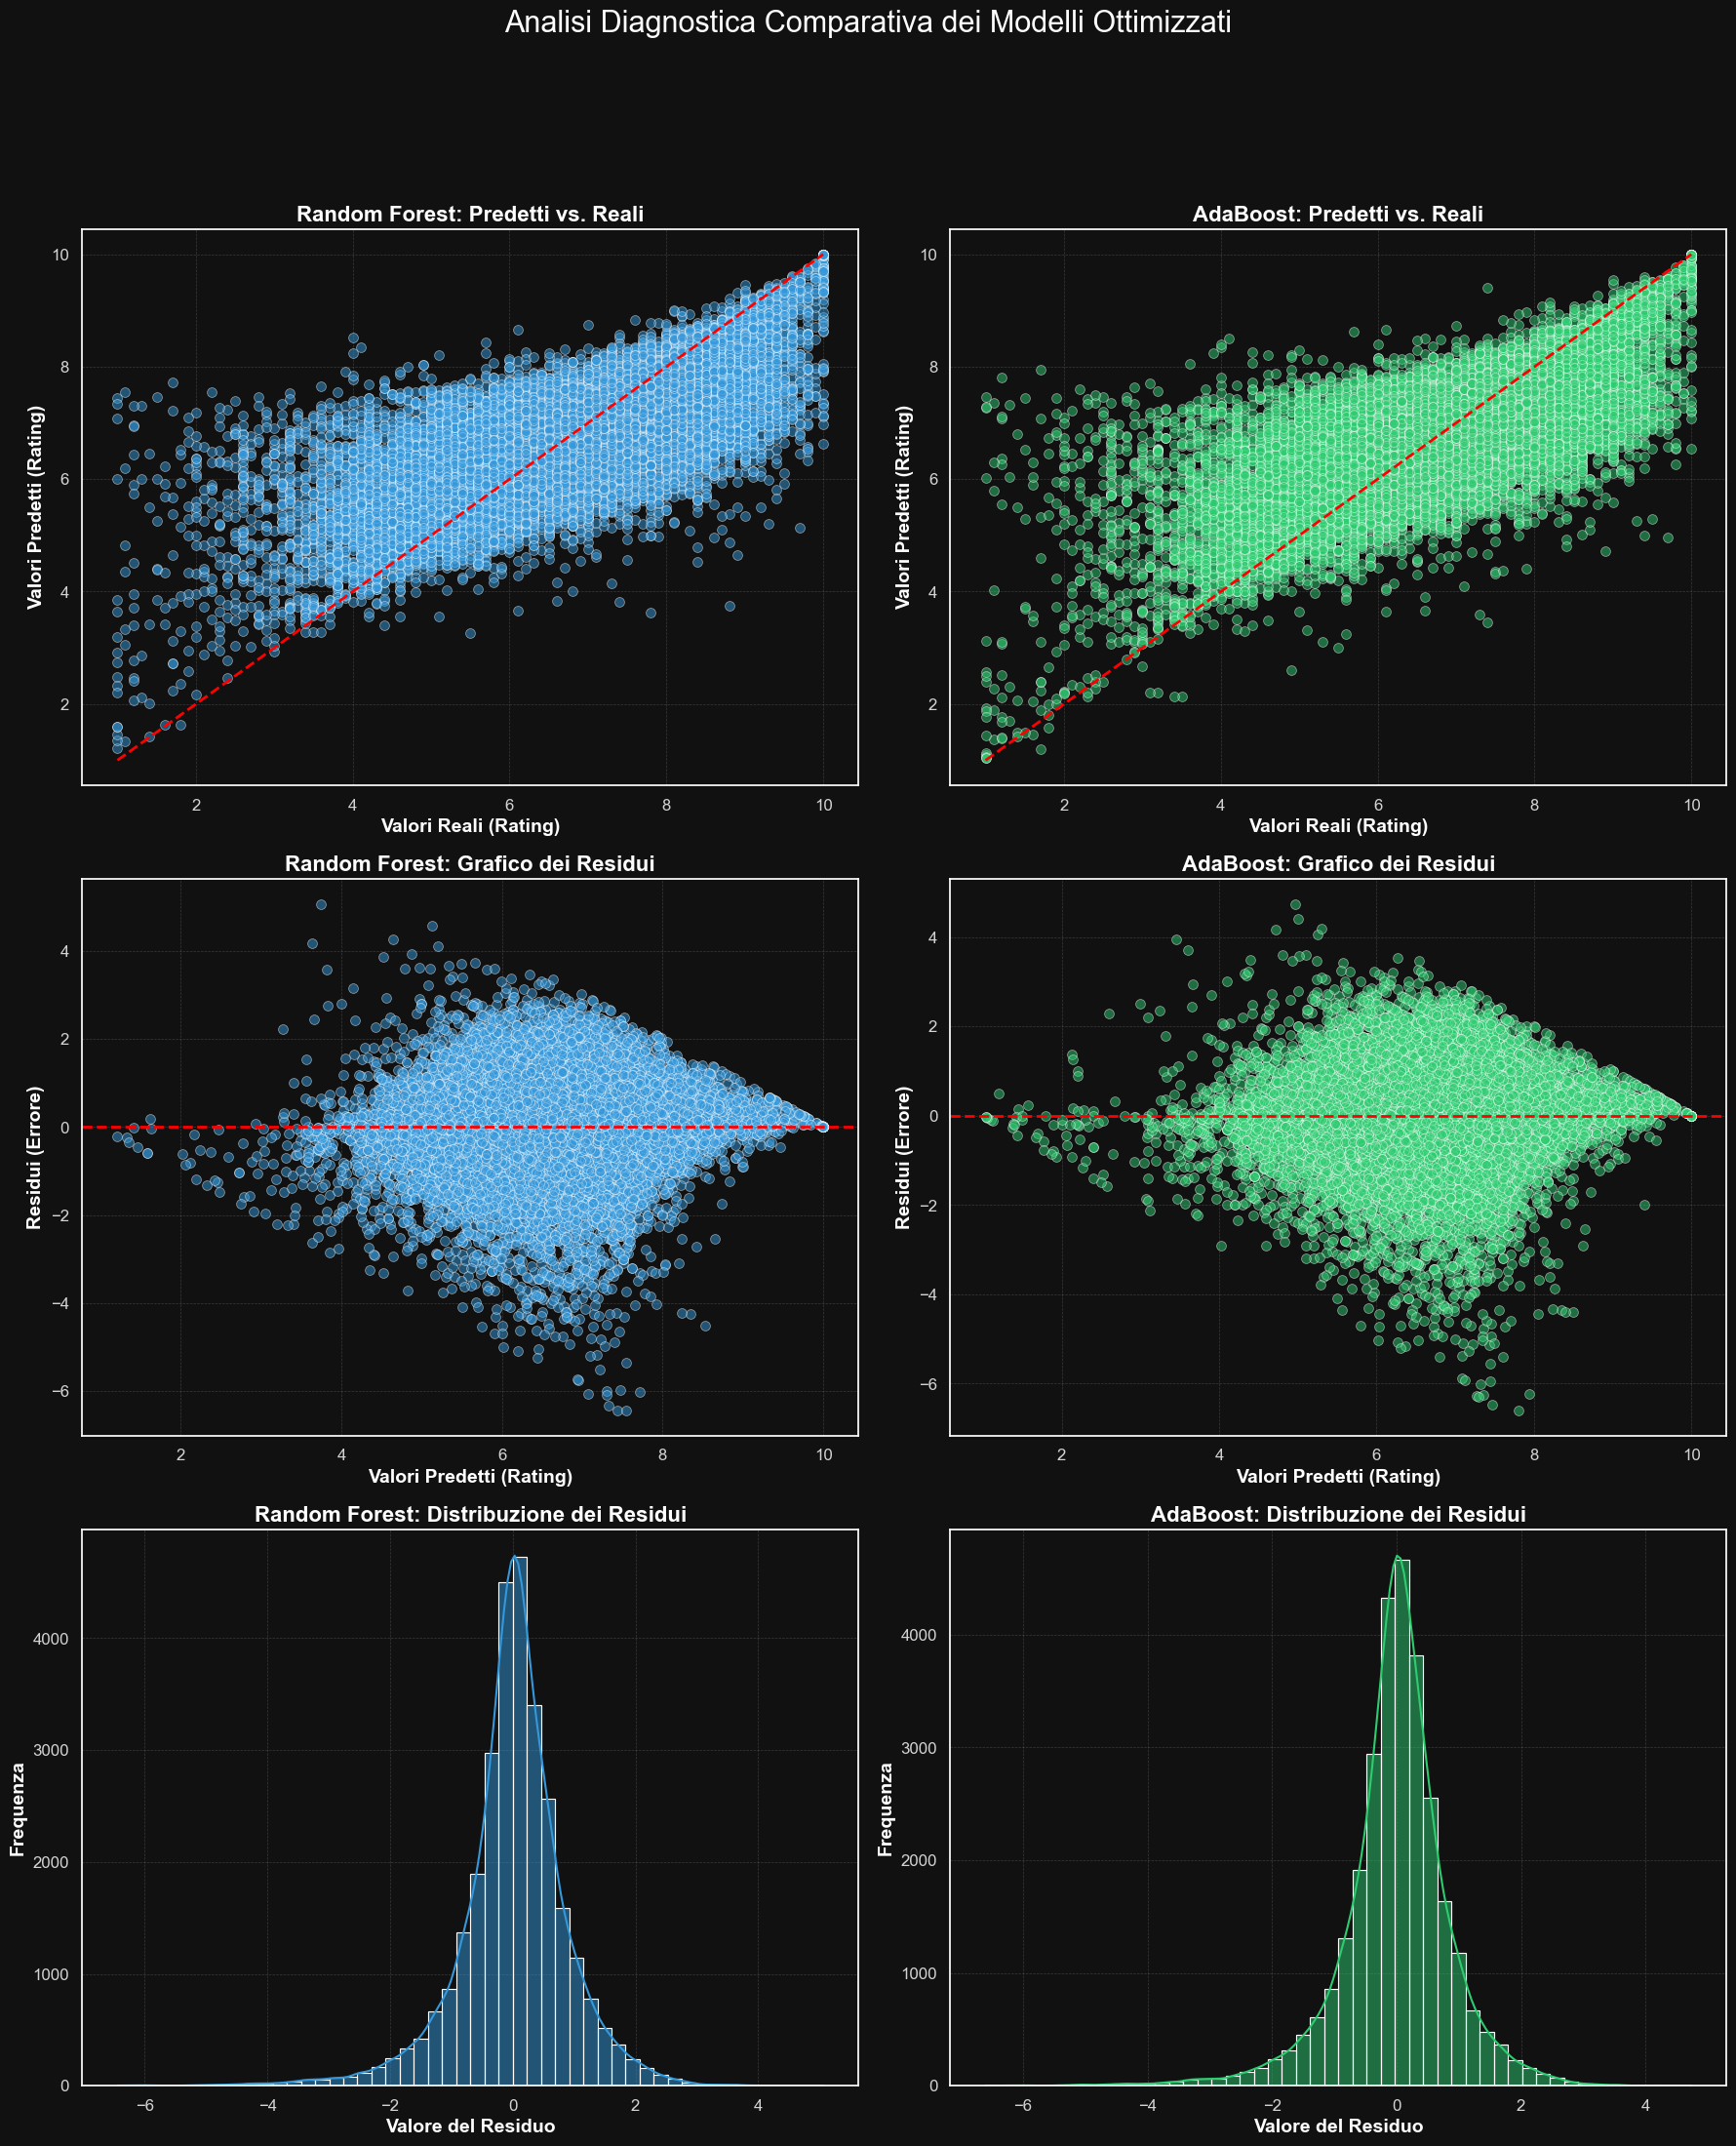

✅ Grafici diagnostici salvati in 'plots_advanced_regression/regression_diagnostics_comparison.png'

Generazione del grafico Feature Importance dal modello RandomForest...


/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_3629/96498404.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


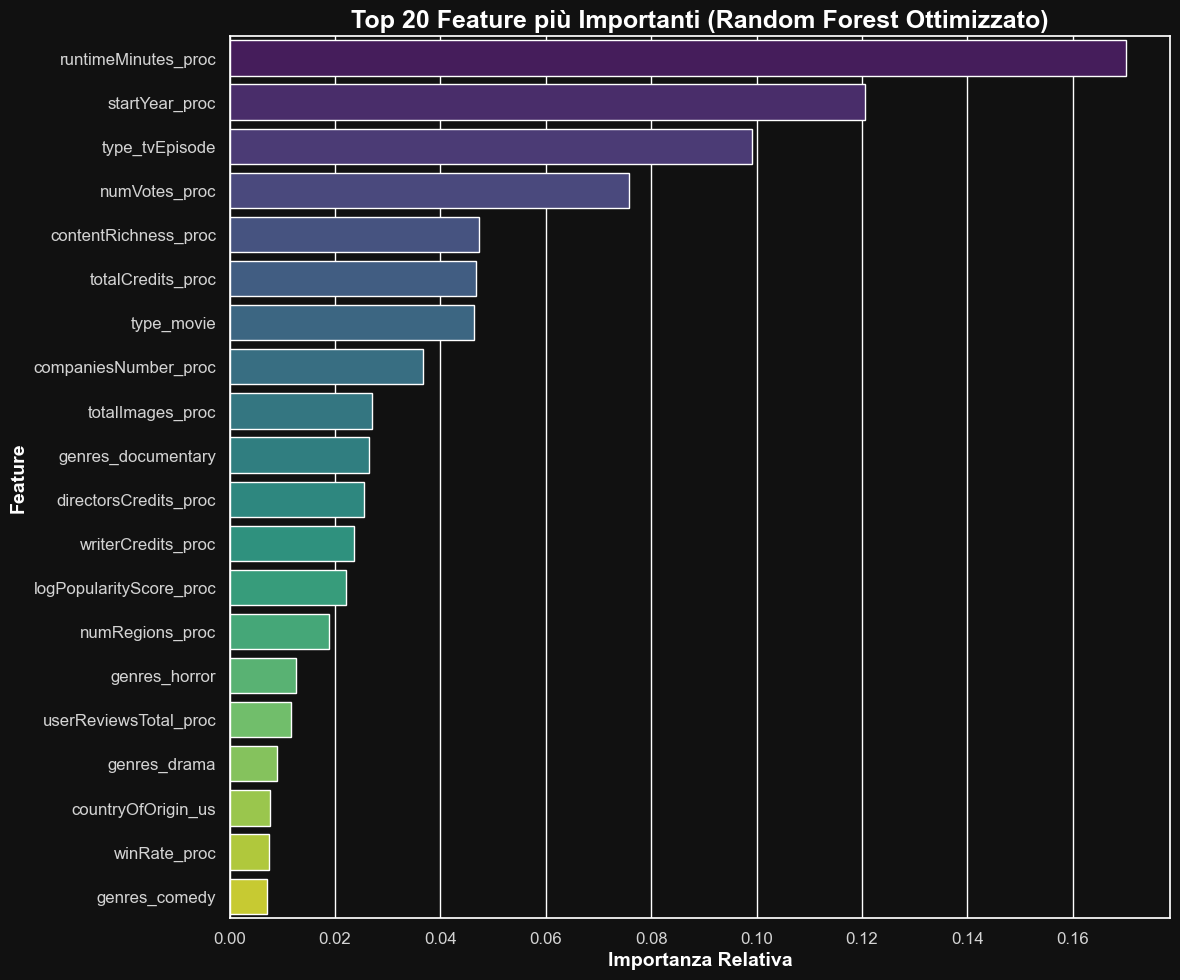

✅ Grafico Feature Importance salvato in 'plots_advanced_regression/feature_importance.png'

✅ Cella di Analisi Finale completata. Siamo pronti per scrivere il report.


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

print("--- CELLA 4: CONFRONTO FINALE E VISUALIZZAZIONE ---")

# 1. Creazione della Tabella Comparativa Finale
final_metrics = {
    'Random Forest (Ottimizzato)': {
        'MAE': mae_rf,
        'RMSE': rmse_rf,
        'R-squared': r2_rf
    },
    'AdaBoost (Ottimizzato)': {
        'MAE': mae_ada,
        'RMSE': rmse_ada,
        'R-squared': r2_ada
    }
}

results_df = pd.DataFrame(final_metrics).T
results_df = results_df.applymap('{:.4f}'.format)  # Formattazione numerica

print("\n--- Tabella Comparativa Finale delle Performance ---")
print(results_df)

# 2. Generazione dei Grafici Diagnostici Comparativi
print("\nGenerazione dei grafici diagnostici per il report...")

residuals_rf = y_test - y_pred_rf
residuals_ada = y_test - y_pred_ada

fig, axes = plt.subplots(3, 2, figsize=(18, 22))
fig.suptitle('Analisi Diagnostica Comparativa dei Modelli Ottimizzati', fontsize=22, y=1.03)

color_rf = '#3498db'
color_ada = '#2ecc71'

# --- RANDOM FOREST ---

# Predetti vs Reali
ax = axes[0, 0]
sns.scatterplot(x=y_test, y=y_pred_rf, ax=ax, alpha=0.5, color=color_rf, s=50)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_title('Random Forest: Predetti vs. Reali', fontsize=16)
ax.set_xlabel('Valori Reali (Rating)', fontsize=14)
ax.set_ylabel('Valori Predetti (Rating)', fontsize=14)
ax.grid(True, color='#999999', linestyle='--', linewidth=0.5, alpha=0.3)


# Grafico dei Residui
ax = axes[1, 0]
sns.scatterplot(x=y_pred_rf, y=residuals_rf, ax=ax, alpha=0.5, color=color_rf, s=50)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_title('Random Forest: Grafico dei Residui', fontsize=16)
ax.set_xlabel('Valori Predetti (Rating)', fontsize=14)
ax.set_ylabel('Residui (Errore)', fontsize=14)
ax.grid(True, color='#999999', linestyle='--', linewidth=0.5, alpha=0.3)


# Distribuzione dei Residui
ax = axes[2, 0]
sns.histplot(residuals_rf, ax=ax, kde=True, color=color_rf, bins=50)
ax.set_title('Random Forest: Distribuzione dei Residui', fontsize=16)
ax.set_xlabel('Valore del Residuo', fontsize=14)
ax.set_ylabel('Frequenza', fontsize=14)
ax.grid(True, color='#999999', linestyle='--', linewidth=0.5, alpha=0.3)


# --- ADABOOST ---

# Predetti vs Reali
ax = axes[0, 1]
sns.scatterplot(x=y_test, y=y_pred_ada, ax=ax, alpha=0.5, color=color_ada, s=50)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_title('AdaBoost: Predetti vs. Reali', fontsize=16)
ax.set_xlabel('Valori Reali (Rating)', fontsize=14)
ax.set_ylabel('Valori Predetti (Rating)', fontsize=14)
ax.grid(True, color='#999999', linestyle='--', linewidth=0.5, alpha=0.3)


# Grafico dei Residui
ax = axes[1, 1]
sns.scatterplot(x=y_pred_ada, y=residuals_ada, ax=ax, alpha=0.5, color=color_ada, s=50)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_title('AdaBoost: Grafico dei Residui', fontsize=16)
ax.set_xlabel('Valori Predetti (Rating)', fontsize=14)
ax.set_ylabel('Residui (Errore)', fontsize=14)
ax.grid(True, color='#999999', linestyle='--', linewidth=0.5, alpha=0.3)


# Distribuzione dei Residui
ax = axes[2, 1]
sns.histplot(residuals_ada, ax=ax, kde=True, color=color_ada, bins=50)
ax.set_title('AdaBoost: Distribuzione dei Residui', fontsize=16)
ax.set_xlabel('Valore del Residuo', fontsize=14)
ax.set_ylabel('Frequenza', fontsize=14)
ax.grid(True, color='#999999', linestyle='--', linewidth=0.5, alpha=0.3)


# Salvataggio del grafico completo
output_path = os.path.join(plots_dir, 'regression_diagnostics_comparison.png')
plt.tight_layout(rect=(0, 0.03, 1, 0.97))
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Grafici diagnostici salvati in '{output_path}'")

# 3. Analisi dell'Importanza delle Feature (dal modello migliore)
print("\nGenerazione del grafico Feature Importance dal modello RandomForest...")

importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance_df.head(20),
    palette='viridis'
)
plt.title('Top 20 Feature più Importanti (Random Forest Ottimizzato)', fontsize=18)
plt.xlabel('Importanza Relativa', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.tight_layout()

output_path_importance = os.path.join(plots_dir, 'feature_importance.png')
plt.savefig(output_path_importance, dpi=300)
plt.show()

print(f"✅ Grafico Feature Importance salvato in '{output_path_importance}'")
print("\n✅ Cella di Analisi Finale completata. Siamo pronti per scrivere il report.")
